In [2]:
import os
print(os.getcwd())

d:\Data analyst price stock\Apple price stock


In [3]:
import os
print("CURRENT FOLDER:", os.getcwd())
print("FILES HERE:", os.listdir())

CURRENT FOLDER: d:\Data analyst price stock\Apple price stock
FILES HERE: ['AAPL.csv', 'AAPL_cleaned.csv', 'AAPL_closing_price.png', 'aapl_graphs.py', 'AAPL_high_low.png', 'AAPL_moving_averages.png', 'AAPL_open_close_comparison.png', 'AAPL_volume.png', 'analysis.ipynb', 'app.py', 'DASHBOARD_PLAN.md', 'README.md', 'requirements.txt']


In [4]:
import os
print(os.listdir(r"D:\Data analyst price stock"))

['Apple price stock', 'archive (1).zip']


In [5]:
import pandas as pd

df = pd.read_csv("AAPL.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099319,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094137,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087228,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089387,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091978,73449600


In [6]:
import pandas as pd
import numpy as np

# Load Apple stock dataset
df = pd.read_csv("AAPL.csv")  

print("=== APPLE STOCK DATA OVERVIEW ===")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())


=== APPLE STOCK DATA OVERVIEW ===
Shape: (10836, 7)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099319,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094137,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087228,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089387,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091978,73449600


In [7]:
# -------------------------------------------------
# 2️⃣ Clean the dataset
# -------------------------------------------------
df_clean = df.copy()   # work on a copy

# 3.1 Drop unnecessary columns (if any exist)
# (Usually Apple dataset already clean hota hai)
cols_to_drop = []  
df_clean.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 3.2 Fix data types
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Ensure numeric columns are correct
num_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df_clean[num_cols] = df_clean[num_cols].apply(pd.to_numeric, errors='coerce')

# 3.3 Sort by Date (VERY IMPORTANT for time series)
df_clean = df_clean.sort_values('Date')

# 3.4 Handle missing values
# Fill numeric columns with forward fill (time-series best practice)
df_clean[num_cols] = df_clean[num_cols].ffill()
df_clean[num_cols] = df_clean[num_cols].bfill()

# If still missing at start → backfill
df_clean[num_cols] = df_clean[num_cols].bfill()

# 3.5 Remove duplicates (if any)
df_clean = df_clean.drop_duplicates()

# 3.6 Feature Engineering (IMPORTANT 🔥)
# Price range (volatility indicator)
df_clean['Price_Range'] = df_clean['High'] - df_clean['Low']

# Daily return
df_clean['Daily_Return'] = df_clean['Close'].pct_change()

# Moving averages
df_clean['MA50'] = df_clean['Close'].rolling(window=50).mean()
df_clean['MA200'] = df_clean['Close'].rolling(window=200).mean()

# 3.7 Final check
print("\n=== CLEANED APPLE STOCK DATA OVERVIEW ===")
print(f"Shape: {df_clean.shape}")

print("\nData types:")
print(df_clean.dtypes)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nFirst 5 rows:")
display(df_clean.head())


=== CLEANED APPLE STOCK DATA OVERVIEW ===
Shape: (10836, 11)

Data types:
Date            datetime64[us]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Adj Close              float64
Volume                   int64
Price_Range            float64
Daily_Return           float64
MA50                   float64
MA200                  float64
dtype: object

Missing values after cleaning:
Date              0
Open              0
High              0
Low               0
Close             0
Adj Close         0
Volume            0
Price_Range       0
Daily_Return      1
MA50             49
MA200           199
dtype: int64

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume,Price_Range,Daily_Return,MA50,MA200
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.099319,469033600,0.000558,NaN,NaN,NaN
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094137,175884800,0.000558,-0.052171,NaN,NaN
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087228,105728000,0.000558,-0.073398,NaN,NaN
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.089387,86441600,0.000558,0.024751,NaN,NaN
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.091978,73449600,0.000558,0.028992,NaN,NaN


In [8]:
# Save cleaned dataset
output_path = "AAPL_cleaned.csv"

df_clean.to_csv(output_path, index=False)

print(f"Dataset saved to: {output_path}")

Dataset saved to: AAPL_cleaned.csv


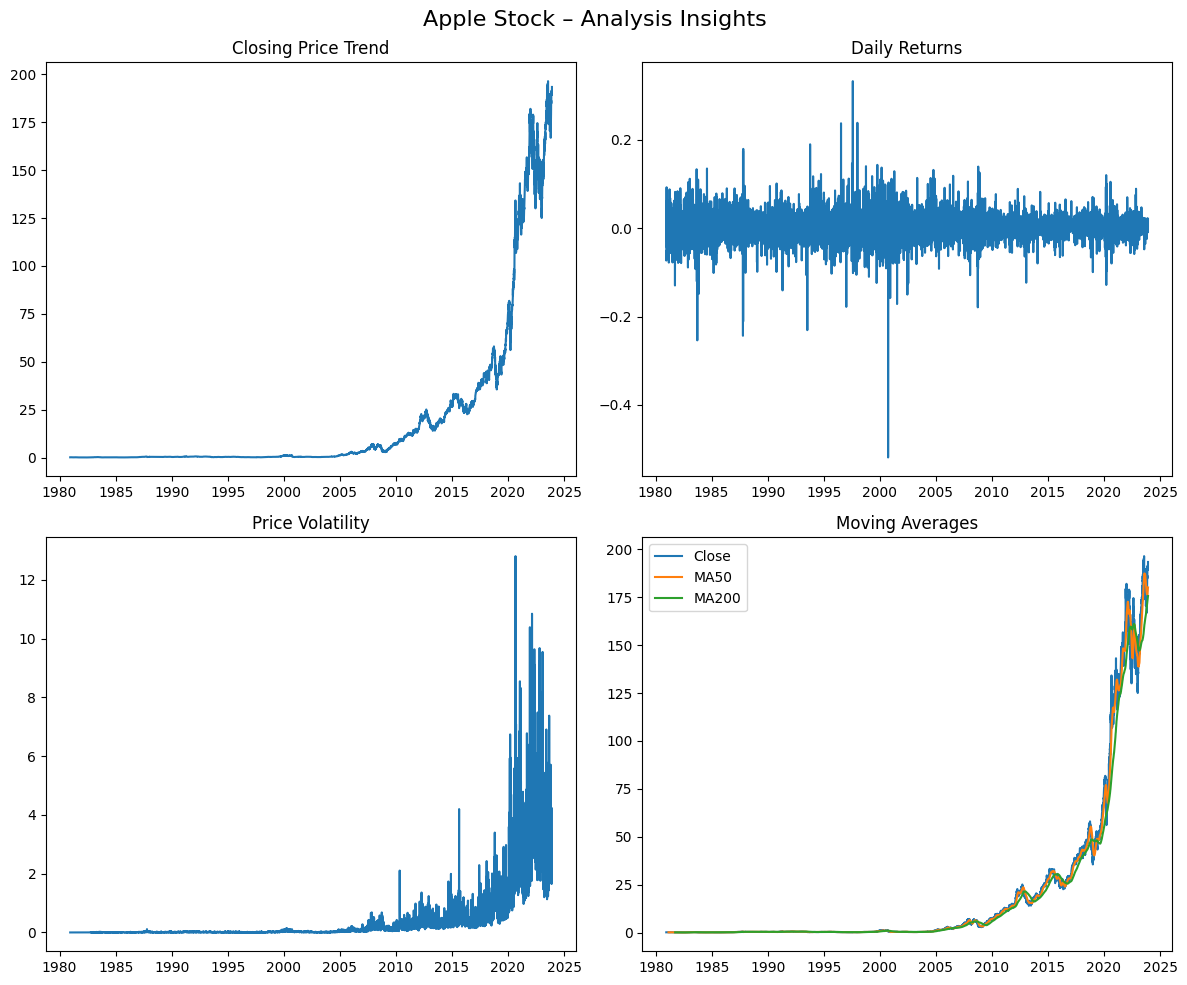

In [ ]:
import matplotlib.pyplot as plt

data = df_clean.copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Apple Stock – Analysis Insights', fontsize=16)

# Closing Price Trend
axes[0, 0].plot(data['Date'], data['Close'])
axes[0, 0].set_title('Closing Price Trend')

# Daily Returns
axes[0, 1].plot(data['Date'], data['Daily_Return'])
axes[0, 1].set_title('Daily Returns')

# Price Range
axes[1, 0].plot(data['Date'], data['Price_Range'])
axes[1, 0].set_title('Price Volatility')

# Moving Averages
axes[1, 1].plot(data['Date'], data['Close'], label='Close')
axes[1, 1].plot(data['Date'], data['MA50'], label='MA50')
axes[1, 1].plot(data['Date'], data['MA200'], label='MA200')
axes[1, 1].legend()
axes[1, 1].set_title('Moving Averages')

plt.tight_layout()
plt.show()
